## Dynamic pricing - EDA

This notebook is for exploration and analysis only. No production logic, no pipeline node is written here

* D1 - data quality must be checked
* D2 - feature distribution and relationship to the target column must be understood

* target column: `Historical_cost_or_ride`

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

In [2]:
# load data

data = pd.read_csv("../data/01_raw/dynamic_pricing.csv")
data.shape

(1000, 10)

### 1. Initial Inspection

In [3]:
data.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


In [5]:
data.describe()

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


In [6]:
data.isna().sum()

Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64

In [7]:
data.describe(include="object").T

,count,unique,top,freq
Location_Category,1000,3,Urban,346
Customer_Loyalty_Status,1000,3,Silver,367
Time_of_Booking,1000,4,Night,276
Vehicle_Type,1000,2,Premium,522


In [8]:
data.describe(include = "number").T

,count,mean,std,min,25%,50%,75%,max
Number_of_Riders,1000.0,60.372000,23.701506,20.000000,40.000000,60.000000,81.000000,100.000000
Number_of_Drivers,1000.0,27.076000,19.068346,5.000000,11.000000,22.000000,38.000000,89.000000
Number_of_Past_Rides,1000.0,50.031000,29.313774,0.000000,25.000000,51.000000,75.000000,100.000000
Average_Ratings,1000.0,4.257220,0.435781,3.500000,3.870000,4.270000,4.632500,5.000000
Expected_Ride_Duration,1000.0,99.588000,49.165450,10.000000,59.750000,102.000000,143.000000,180.000000
Historical_Cost_of_Ride,1000.0,372.502623,187.158756,25.993449,221.365202,362.019426,510.497504,836.116419


### 2. Data Quality checks

In [9]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
quality_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
quality_report[quality_report["missing_count"] > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_pct


In [10]:
n_duplicates = data.duplicated().sum()
print(f"Duplicate rows: {n_duplicates} ({n_duplicates / len(data) * 100:.2f}% of dataset)")

Duplicate rows: 0 (0.00% of dataset)


### 3. Target Column

Understanding the target column distribution is important for two reasons:

* it tell whether a transform(eg. log) help modeling later
* sets the scale RSME/MAE will be jugde against

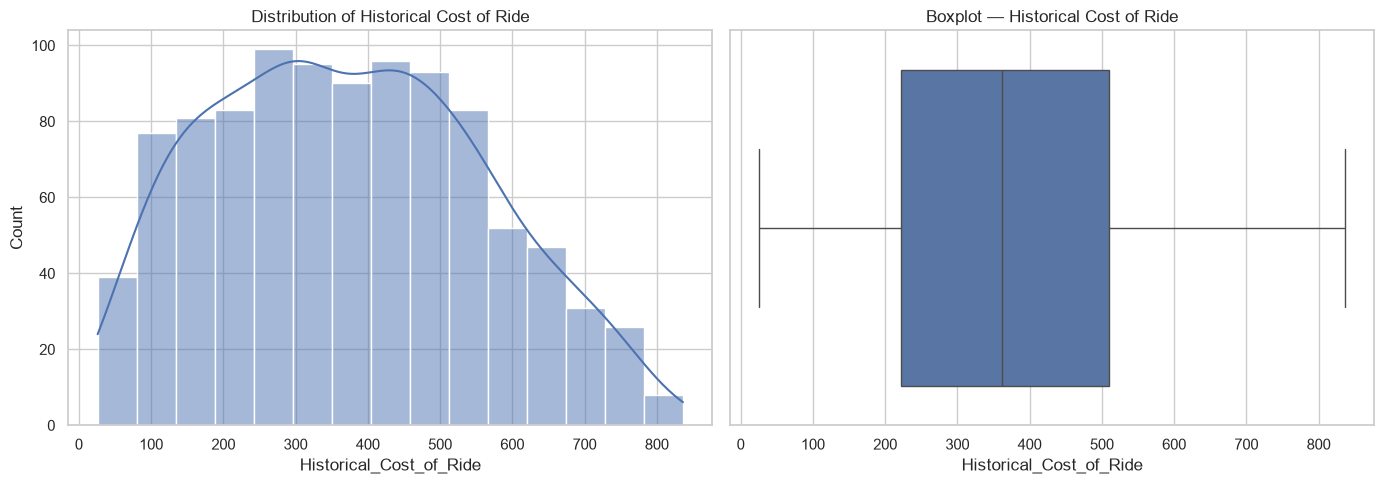

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data["Historical_Cost_of_Ride"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Historical Cost of Ride")

sns.boxplot(x=data["Historical_Cost_of_Ride"], ax=axes[1])
axes[1].set_title("Boxplot — Historical Cost of Ride")

plt.tight_layout()
plt.show()

In [12]:
print("Skewness:", data["Historical_Cost_of_Ride"].skew().round(3))
print("Kurtosis:", data["Historical_Cost_of_Ride"].kurt().round(3))

Skewness: 0.21
Kurtosis: -0.777


### 4. Numeric Feature Distribution

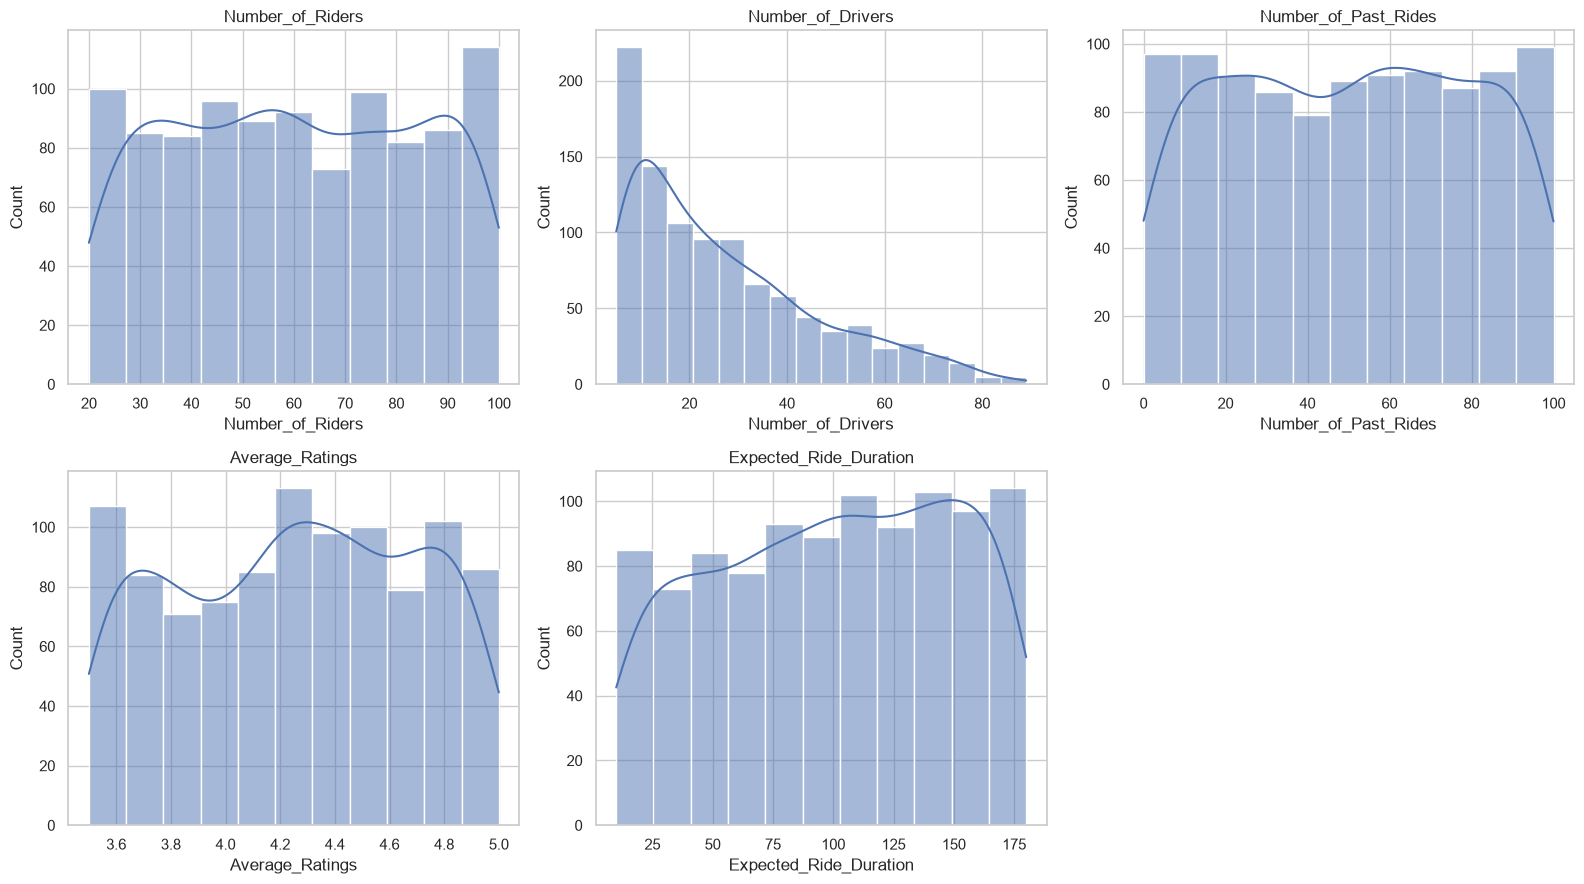

In [13]:
numeric_cols = [
    "Number_of_Riders",
    "Number_of_Drivers",
    "Number_of_Past_Rides",
    "Average_Ratings",
    "Expected_Ride_Duration",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

# hide the unused 6th subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [14]:
data[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Number_of_Riders,1000.0,60.37200,23.701506,20.0,40.00,60.00,81.0000,100.0
Number_of_Drivers,1000.0,27.07600,19.068346,5.0,11.00,22.00,38.0000,89.0
Number_of_Past_Rides,1000.0,50.03100,29.313774,0.0,25.00,51.00,75.0000,100.0
Average_Ratings,1000.0,4.25722,0.435781,3.5,3.87,4.27,4.6325,5.0
Expected_Ride_Duration,1000.0,99.58800,49.165450,10.0,59.75,102.00,143.0000,180.0


### 5. Categorical Feature Distributions

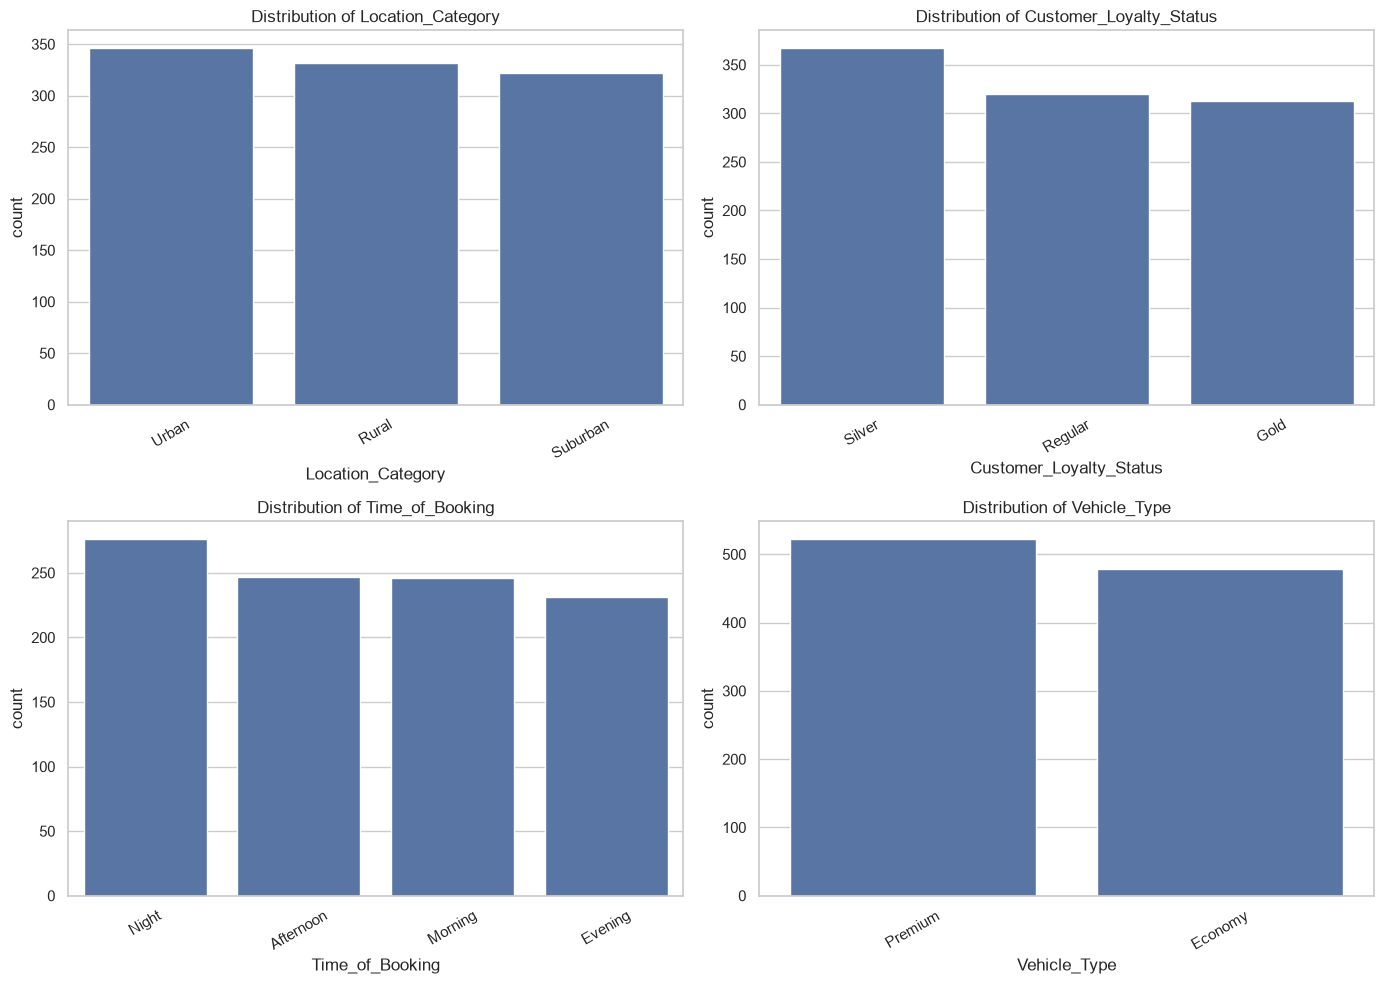

In [15]:
categorical_cols = [
    "Location_Category",
    "Customer_Loyalty_Status",
    "Time_of_Booking",
    "Vehicle_Type",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = data[col].value_counts().index
    sns.countplot(data=data, x=col, order=order, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [16]:
for col in categorical_cols:
    print(f"--- {col} ---")
    print(data[col].value_counts(normalize=True).round(3) * 100)
    print()

--- Location_Category ---
Location_Category
Urban       34.6
Rural       33.2
Suburban    32.2
Name: proportion, dtype: float64

--- Customer_Loyalty_Status ---
Customer_Loyalty_Status
Silver     36.7
Regular    32.0
Gold       31.3
Name: proportion, dtype: float64

--- Time_of_Booking ---
Time_of_Booking
Night        27.6
Afternoon    24.7
Morning      24.6
Evening      23.1
Name: proportion, dtype: float64

--- Vehicle_Type ---
Vehicle_Type
Premium    52.2
Economy    47.8
Name: proportion, dtype: float64



### 6. Categorical Features vs. Target

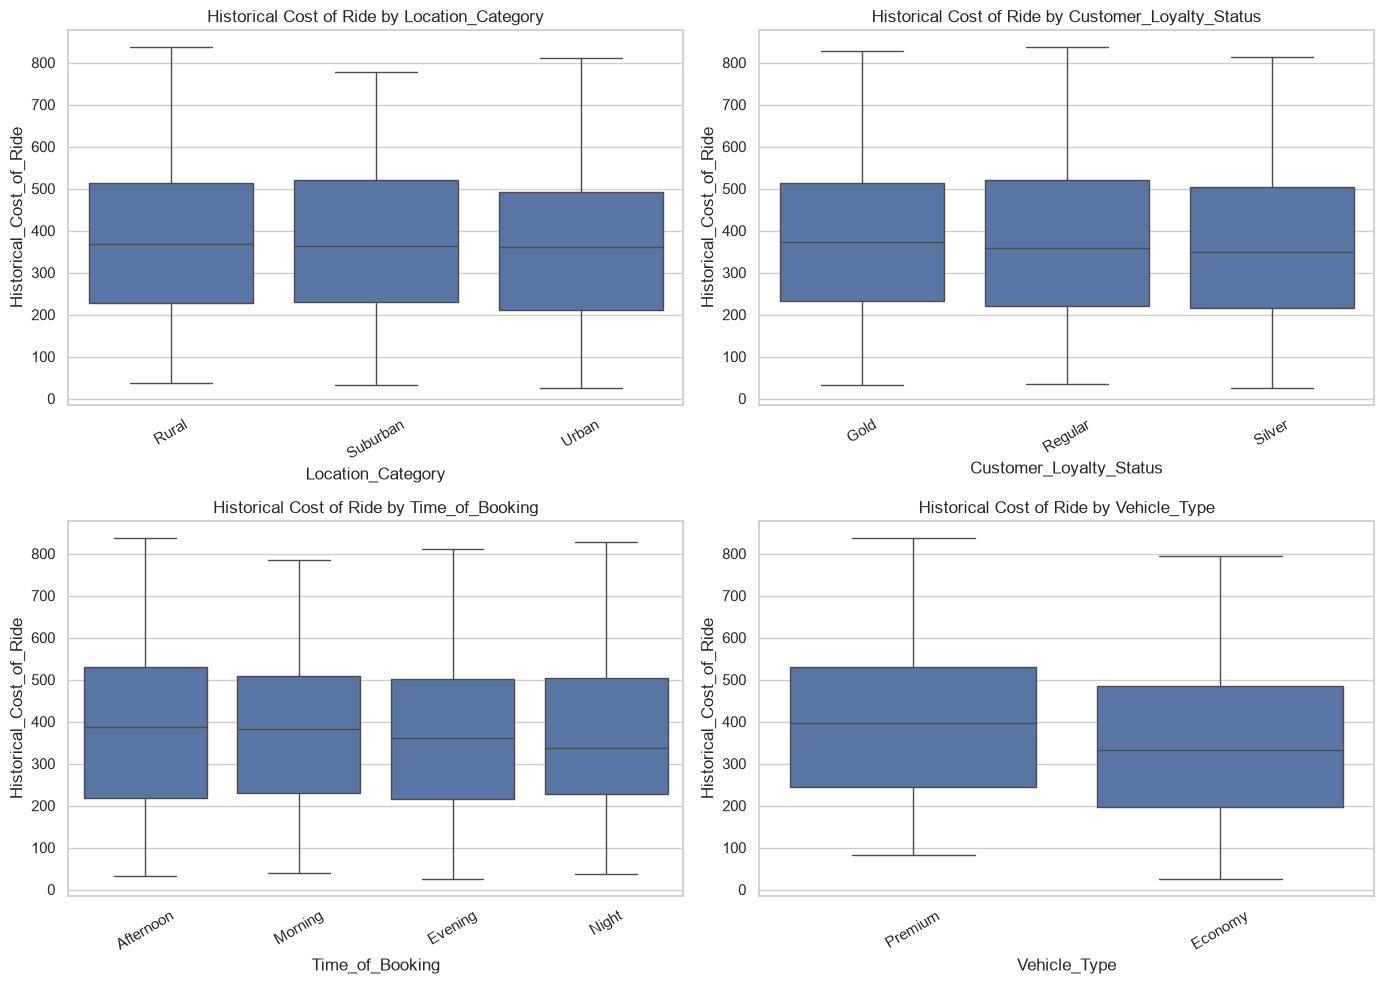

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = data.groupby(col)["Historical_Cost_of_Ride"].median().sort_values(ascending=False).index
    sns.boxplot(data=data, x=col, y="Historical_Cost_of_Ride", order=order, ax=axes[i])
    axes[i].set_title(f"Historical Cost of Ride by {col}")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [18]:
for col in categorical_cols:
    print(f"--- Median cost by {col} ---")
    print(data.groupby(col)["Historical_Cost_of_Ride"].median().sort_values(ascending=False).round(2))
    print()

--- Median cost by Location_Category ---
Location_Category
Rural       367.76
Suburban    362.70
Urban       359.96
Name: Historical_Cost_of_Ride, dtype: float64

--- Median cost by Customer_Loyalty_Status ---
Customer_Loyalty_Status
Gold       373.98
Regular    358.95
Silver     348.67
Name: Historical_Cost_of_Ride, dtype: float64

--- Median cost by Time_of_Booking ---
Time_of_Booking
Afternoon    387.48
Morning      382.23
Evening      360.71
Night        336.09
Name: Historical_Cost_of_Ride, dtype: float64

--- Median cost by Vehicle_Type ---
Vehicle_Type
Premium    397.59
Economy    331.23
Name: Historical_Cost_of_Ride, dtype: float64



### 7. Correlation Analysis(Numeric Features)

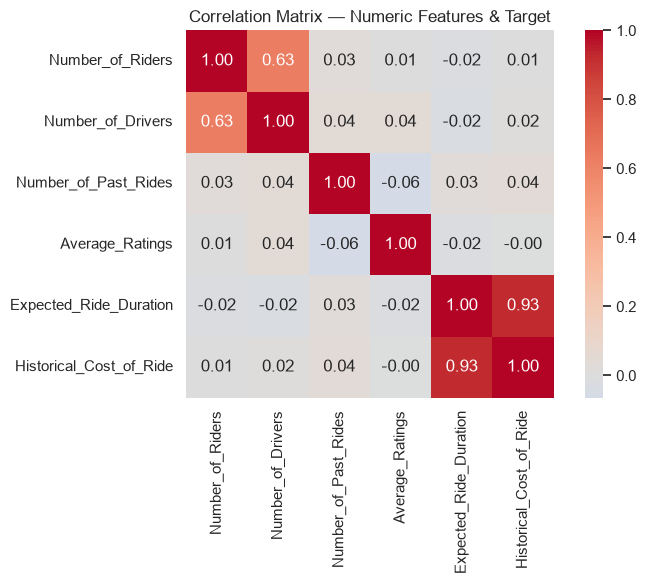

In [19]:
corr = data[numeric_cols + ["Historical_Cost_of_Ride"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix — Numeric Features & Target")
plt.tight_layout()
plt.show()

In [20]:
corr["Historical_Cost_of_Ride"].drop("Historical_Cost_of_Ride").sort_values(ascending=False)

Expected_Ride_Duration    0.927547
Number_of_Past_Rides      0.035859
Number_of_Drivers         0.017082
Number_of_Riders          0.005826
Average_Ratings          -0.001063
Name: Historical_Cost_of_Ride, dtype: float64

### 8. Demand-Supply ration vs. Cost

This is the central hypothesis behind the whole project: cost should rise as the ratio of riders to drivers increases. Engineered here for exploration only — the actual feature engineering node will live in `pipelines/feature_engineering/` later.

In [21]:
data["demand_supply_ratio"] = data["Number_of_Riders"] / data["Number_of_Drivers"]

data["demand_supply_ratio"].describe()

count    1000.000000
mean        3.235461
std         2.533519
min         1.112360
25%         1.658793
50%         2.357143
75%         3.800000
max        17.600000
Name: demand_supply_ratio, dtype: float64

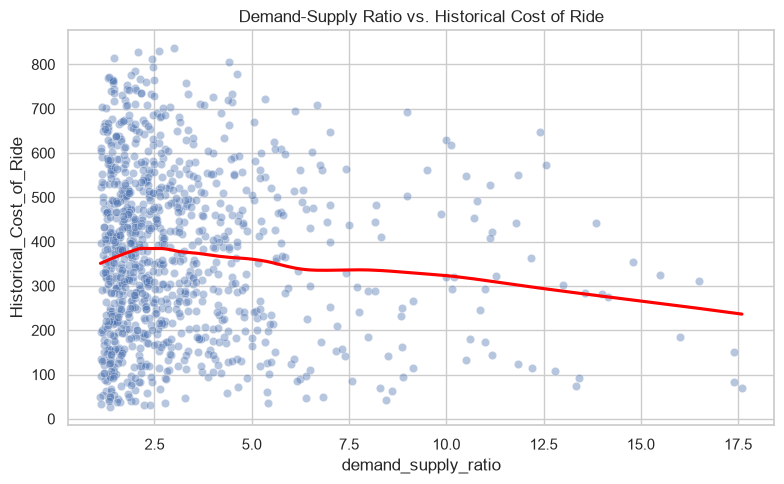

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="demand_supply_ratio", y="Historical_Cost_of_Ride", alpha=0.4)
sns.regplot(data=data, x="demand_supply_ratio", y="Historical_Cost_of_Ride",
            scatter=False, color="red", lowess=True)
plt.title("Demand-Supply Ratio vs. Historical Cost of Ride")
plt.tight_layout()
plt.show()

In [23]:
print("Correlation (demand_supply_ratio, cost):",
      data["demand_supply_ratio"].corr(data["Historical_Cost_of_Ride"]).round(3))

Correlation (demand_supply_ratio, cost): -0.094


### 9. Expected Ride Duration vs. Cost

This relationship is what the company's *current* pricing model relies on exclusively. Understanding how strong (or weak) it is on its own sets expectations for how much the baseline model can achieve.

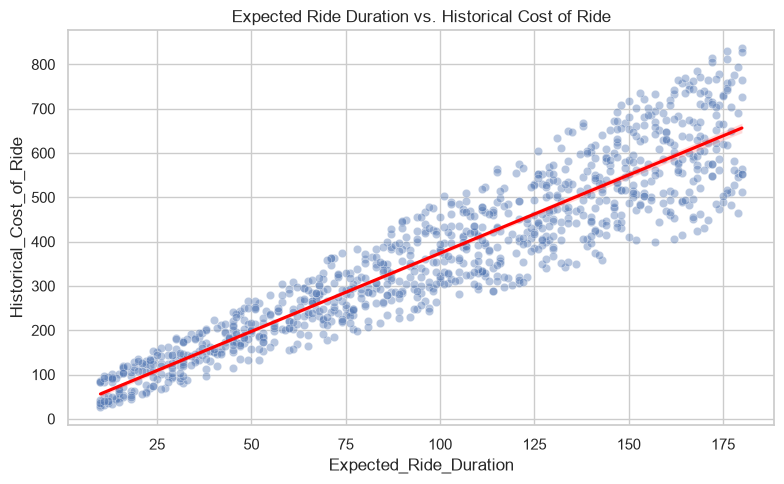

In [24]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="Expected_Ride_Duration", y="Historical_Cost_of_Ride", alpha=0.4)
sns.regplot(data=data, x="Expected_Ride_Duration", y="Historical_Cost_of_Ride",
            scatter=False, color="red")
plt.title("Expected Ride Duration vs. Historical Cost of Ride")
plt.tight_layout()
plt.show()

In [25]:
print("Correlation (duration, cost):",
      data["Expected_Ride_Duration"].corr(data["Historical_Cost_of_Ride"]).round(3))

Correlation (duration, cost): 0.928


### 10. Outlier Check(IQR method)

Flagging outliers here for awareness — decisions on capping/removal belong in the feature engineering pipeline, not this notebook, and should be justified by what's found below rather than applied blindly.

In [26]:
def iqr_outlier_summary(series, name):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    print(f"{name:30s} lower={lower:>10.2f}  upper={upper:>10.2f}  outliers={n_outliers} ({n_outliers/len(series)*100:.2f}%)")

for col in numeric_cols + ["Historical_Cost_of_Ride", "demand_supply_ratio"]:
    iqr_outlier_summary(data[col], col)

Number_of_Riders               lower=    -21.50  upper=    142.50  outliers=0 (0.00%)
Number_of_Drivers              lower=    -29.50  upper=     78.50  outliers=10 (1.00%)
Number_of_Past_Rides           lower=    -50.00  upper=    150.00  outliers=0 (0.00%)
Average_Ratings                lower=      2.73  upper=      5.78  outliers=0 (0.00%)
Expected_Ride_Duration         lower=    -65.12  upper=    267.88  outliers=0 (0.00%)
Historical_Cost_of_Ride        lower=   -212.33  upper=    944.20  outliers=0 (0.00%)
demand_supply_ratio            lower=     -1.55  upper=      7.01  outliers=70 (7.00%)


In [27]:
# quick sanity check before committing to feature set
from sklearn.ensemble import RandomForestRegressor

X = pd.get_dummies(data.drop(columns=["Historical_Cost_of_Ride"]), drop_first=True)
y = data["Historical_Cost_of_Ride"]

rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X, y)

pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

Expected_Ride_Duration             0.881109
Average_Ratings                    0.020749
demand_supply_ratio                0.018871
Number_of_Past_Rides               0.018702
Number_of_Riders                   0.016103
Number_of_Drivers                  0.013862
Vehicle_Type_Premium               0.012883
Customer_Loyalty_Status_Regular    0.002816
Location_Category_Urban            0.002748
Time_of_Booking_Morning            0.002696
Time_of_Booking_Evening            0.002623
Time_of_Booking_Night              0.002537
Customer_Loyalty_Status_Silver     0.002180
Location_Category_Suburban         0.002119
dtype: float64

In [28]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf, X, y, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

Expected_Ride_Duration             1.799570
Vehicle_Type_Premium               0.042050
Average_Ratings                    0.028882
demand_supply_ratio                0.025266
Number_of_Past_Rides               0.023628
Number_of_Riders                   0.018292
Number_of_Drivers                  0.017471
Location_Category_Urban            0.004233
Time_of_Booking_Evening            0.004159
Customer_Loyalty_Status_Regular    0.004043
Time_of_Booking_Night              0.003451
Time_of_Booking_Morning            0.003145
Location_Category_Suburban         0.002712
Customer_Loyalty_Status_Silver     0.002577
dtype: float64